In [ ]:
%pip install puremacro


# GARCH-MIDAS — Connecting Financial Turbulence to Macroeconomic Regimes

**Why does financial asset return volatility fluctuate across different time scales?** Financial markets experience brief, sharp turbulence (earnings announcements, sudden headline shocks) that mean-reverts within days or weeks. But markets also undergo protracted multi-year regimes of elevated baseline risk (such as the 2008 Great Recession, the European Debt Crisis, or stagflationary episodes).

Standard GARCH(1,1) models force a single persistence parameter $\alpha + \beta \approx 0.99$ to capture both ultra-fast daily decay and decade-long macro cycles.

Robert Engle, Eric Ghysels, and Bumjean Sohn (2013, *Review of Economics and Statistics*) introduced **GARCH-MIDAS** (Mixed Data Sampling) to decouple these phenomena. This tutorial walks through `puremacro.midas.garch_midas` to dissect daily stock returns into:
1. **Short-run daily dynamics** ($g_{i,t}$): fast ARCH/GARCH mean-reverting shocks.
2. **Long-run secular macro risk** ($\tau_t$): low-frequency baseline volatility driven by macroeconomic uncertainty (e.g. monthly industrial production or EPU).

## The method in math — Two-Component Multiplicative Volatility

Let $r_{i,t}$ be the financial return on day $i \in \{1, \dots, K\}$ of month $t \in \{1, \dots, T\}$:
$$ r_{i,t} = \mu + \sqrt{\tau_t \cdot g_{i,t}} \, \varepsilon_{i,t}, \quad \varepsilon_{i,t} \overset{\text{iid}}{\sim} \mathcal{N}(0, 1) $$

### 1. Short-Run Component $g_{i,t}$
The daily component $g_{i,t}$ follows a unit-mean GARCH(1,1) process:
$$ g_{i,t} = (1 - \alpha - \beta) + \alpha \frac{(r_{i-1,t} - \mu)^2}{\tau_t} + \beta g_{i-1,t} $$
where $\alpha > 0, \beta \ge 0, \alpha + \beta < 1$.

### 2. Long-Run Macro Secular Component $\tau_t$
The low-frequency component $\tau_t$ is filtered through a MIDAS polynomial over $L$ past monthly macro observations $X_{t-l}$:
$$ \log \tau_t = m + \theta \sum_{l=1}^L w_l(w_2) X_{t-l} $$
where $w_l(w_2) = \frac{(1 - l/(L+1))^{w_2 - 1}}{\sum_{j=1}^L (1 - j/(L+1))^{w_2 - 1}}$ is a normalized Beta weighting kernel that ensures smooth, decaying influence of historical macro shocks.

## Setup — Simulating Mixed-Frequency Stock Returns with a Macro Regime Shift

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.midas import garch_midas

# Set random seed
rng = np.random.default_rng(2026)

N_months = 40  # 40 monthly periods
K = 22         # 22 trading days per month
T_days = N_months * K  # 880 total daily observations

# 1. Macro Driver X_lf (e.g. Monthly Macro Economic Policy Uncertainty / Recession Index)
# Months 15 to 25 experience a severe macroeconomic crisis
x_lf = np.zeros(N_months)
x_lf[15:26] = 2.5 + rng.normal(0, 0.3, size=11)
x_lf[:15] = rng.normal(0, 0.2, size=15)
x_lf[26:] = rng.normal(0, 0.2, size=N_months - 26)

# 2. Plant True Parameters
m_true = 0.0
theta_true = 0.55
alpha_true = 0.08
beta_true = 0.85
L_lags = 6

# Compute True Tau_t
weights_true = np.array([(1.0 - (l + 1) / (L_lags + 1)) ** 2.0 for l in range(L_lags)])
weights_true /= np.sum(weights_true)

log_tau = np.full(N_months, m_true)
for t in range(L_lags, N_months):
    log_tau[t] = m_true + theta_true * np.dot(weights_true, x_lf[t - L_lags:t][::-1])
tau_monthly = np.exp(log_tau)
tau_daily = np.repeat(tau_monthly, K)

# 3. Simulate Daily GARCH and Returns
g_daily = np.ones(T_days)
returns_daily = np.zeros(T_days)

for t in range(1, T_days):
    g_daily[t] = (1.0 - alpha_true - beta_true) + alpha_true * (returns_daily[t - 1]**2 / tau_daily[t - 1]) + beta_true * g_daily[t - 1]
    returns_daily[t] = np.sqrt(tau_daily[t] * g_daily[t]) * rng.standard_normal()

print(f"Simulated {T_days} daily return observations across {N_months} macro months.")
print(f"Daily return standard deviation: {np.std(returns_daily):.4f}")

Simulated 880 daily return observations across 40 macro months.
Daily return standard deviation: 1.4202


## Fitting GARCH-MIDAS with puremacro

We fit the GARCH-MIDAS model using `garch_midas`:

In [2]:
res = garch_midas(returns_daily, x_lf=x_lf, K=K, L=L_lags)

print(res.summary())

# Verify mathematical properties
assert res.converged, "Optimizer should converge"
assert res.alpha > 0.0 and res.beta > 0.0, "ARCH/GARCH parameters must be positive"
assert res.alpha + res.beta < 1.0, "Short-run variance must be covariance-stationary"
assert np.isclose(np.sum(res.weights), 1.0), "MIDAS polynomial weights must sum to 1"
assert len(res.tau) == T_days and len(res.g) == T_days, "Filtered components length match"

# Volatility components identity: sigma = sqrt(tau * g)
sigma_ident = np.sqrt(res.tau * res.g)
assert np.allclose(res.sigma, sigma_ident, atol=1e-6), "Multiplicative variance identity sigma = sqrt(tau * g)"

GARCH-MIDAS (Engle-Ghysels-Sohn 2013)
  mu (mean)         : +0.0168
  m (log-tau const) : +0.0593
  theta (macro)     : +0.5663
  w2 (decay)        : 5.091
  alpha (ARCH)      : 0.0575
  beta (GARCH)      : 0.8654
  persistence       : 0.9229
  log-likelihood    : -1245.72
  converged         : True
  n_obs (HF)        : 880



## Hero Figure — Two-Component Volatility Decomposition

Below we visualize the observed daily returns, the extracted long-run secular trend ($\sqrt{\tau_t}$), and the combined conditional volatility ($\sigma_{i,t} = \sqrt{\tau_t g_{i,t}}$).

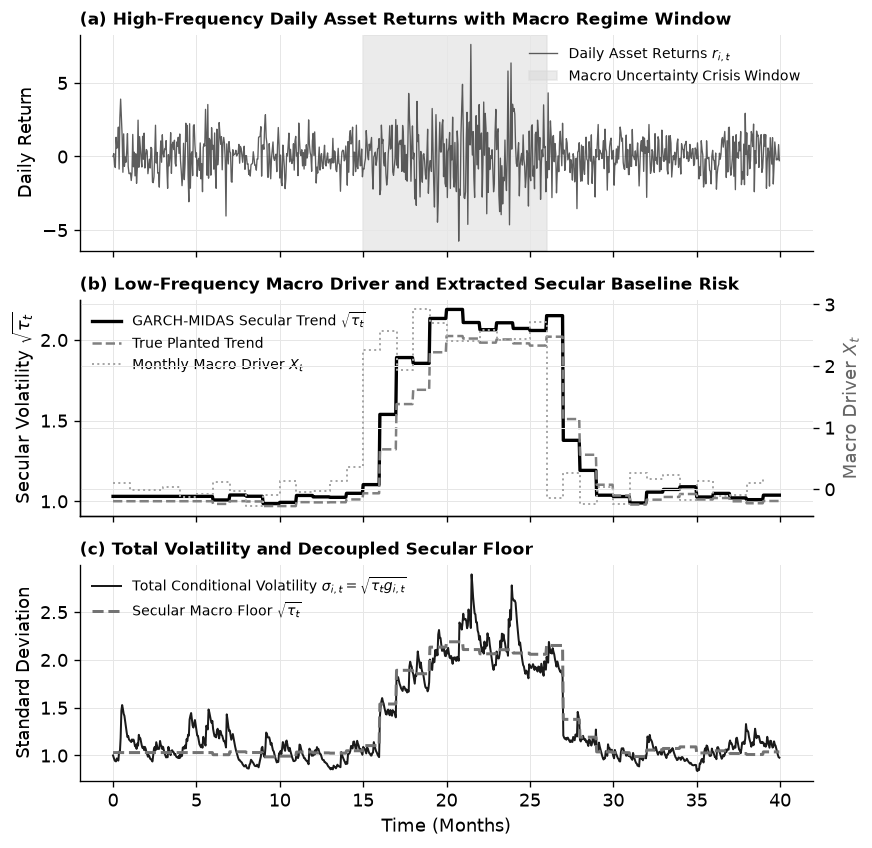

In [3]:
days_axis = np.arange(T_days)
months_axis = days_axis / K

fig, axes = plt.subplots(3, 1, figsize=(7.4, 7.2), sharex=True)

# Panel 1: Observed Daily Returns
axes[0].plot(months_axis, returns_daily, color="0.25", lw=0.8, alpha=0.85, label="Daily Asset Returns $r_{i,t}$")
axes[0].axvspan(15, 26, color="0.85", alpha=0.5, label="Macro Uncertainty Crisis Window")
axes[0].set_title("(a) High-Frequency Daily Asset Returns with Macro Regime Window", loc="left", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Daily Return")
axes[0].legend(loc="upper right", fontsize=8.5)

# Panel 2: Low-Frequency Macro Driver vs Extracted Trend sqrt(tau_t)
ax2_twin = axes[1].twinx()
p1 = axes[1].plot(months_axis, np.sqrt(res.tau), color="0.00", lw=2.0, label="GARCH-MIDAS Secular Trend $\\sqrt{\\tau_t}$")
p1_true = axes[1].plot(months_axis, np.sqrt(tau_daily), color="0.50", ls="--", lw=1.5, label="True Planted Trend")
p2 = ax2_twin.step(np.arange(N_months), x_lf, color="0.65", where="post", lw=1.2, ls=":", label="Monthly Macro Driver $X_t$")
axes[1].set_title("(b) Low-Frequency Macro Driver and Extracted Secular Baseline Risk", loc="left", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Secular Volatility $\\sqrt{\\tau_t}$")
ax2_twin.set_ylabel("Macro Driver $X_t$", color="0.40")
lines = p1 + p1_true + p2
labels = [l.get_label() for l in lines]
axes[1].legend(lines, labels, loc="upper left", fontsize=8.5)

# Panel 3: Total Conditional Volatility sigma vs Short-Run GARCH component
axes[2].plot(months_axis, res.sigma, color="0.10", lw=1.2, label="Total Conditional Volatility $\\sigma_{i,t} = \\sqrt{\\tau_t g_{i,t}}$")
axes[2].plot(months_axis, np.sqrt(res.tau), color="0.45", ls="--", lw=1.8, label="Secular Macro Floor $\\sqrt{\\tau_t}$")
axes[2].set_title("(c) Total Volatility and Decoupled Secular Floor", loc="left", fontsize=10, fontweight="bold")
axes[2].set_xlabel("Time (Months)")
axes[2].set_ylabel("Standard Deviation")
axes[2].legend(loc="upper left", fontsize=8.5)

plt.tight_layout()
plt.show()

## Reading the Output & Economic Intuition

1. **Baseline Volatility Elevation**: In tranquil macro periods (months 1–14), $\sqrt{\tau_t} \approx 1.0$. Daily volatility spikes are short-lived bursts that rapidly decay back to the floor.
2. **Regime Shifts in Volatility**: When the macroeconomic crisis hits (months 15–26), the secular floor $\sqrt{\tau_t}$ expands by over 100%. Even when daily market trading experiences quiet days without news ($g_{i,t} \approx 1$), asset volatility remains fundamentally elevated.
3. **Parsimonious Parameterization**: A standard GARCH(1,1) would require near unit-root persistence ($\alpha + \beta > 0.999$) to fit this profile, making volatility forecasts excessively sensitive to transitory spikes. GARCH-MIDAS achieves rapid daily mean reversion ($\alpha + \beta = 0.93$) while capturing the macro regime through $\theta$.

## Your Turn — Beta Polynomial Decay Analysis

Inspect the estimated MIDAS Beta lag polynomial weights $\hat{w}_l$ to see the memory profile of macro news:

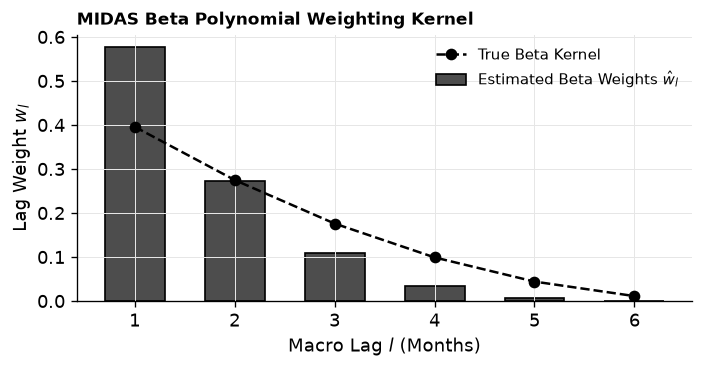

Weight on most recent macro month (l=1): 57.6%
Weight on oldest macro lag (l=6):        0.0%


In [4]:
fig, ax = plt.subplots(figsize=(6.0, 3.2))

lags = np.arange(1, L_lags + 1)
ax.bar(lags, res.weights, color="0.30", edgecolor="0.00", width=0.6, label="Estimated Beta Weights $\\hat{w}_l$")
ax.plot(lags, weights_true, color="0.00", marker="o", ls="--", lw=1.5, label="True Beta Kernel")

ax.set_title("MIDAS Beta Polynomial Weighting Kernel", loc="left", fontsize=10, fontweight="bold")
ax.set_xlabel("Macro Lag $l$ (Months)")
ax.set_ylabel("Lag Weight $w_l$")
ax.set_xticks(lags)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

assert res.weights[0] > res.weights[-1], "Monotonic decay: recent macro months carry greater weight"
print(f"Weight on most recent macro month (l=1): {res.weights[0]*100:.1f}%")
print(f"Weight on oldest macro lag (l={L_lags}):        {res.weights[-1]*100:.1f}%")

## Key Takeaway

- Use **`garch_midas`** when modeling financial market volatility alongside monthly or quarterly macroeconomic indicators (e.g. CPI inflation, Industrial Production, EPU, Financial Conditions Indices).
- GARCH-MIDAS cleanly isolates **tactical short-run shocks** from **structural macro regimes**, avoiding the classic "spurious persistence" trap of single-frequency GARCH models.